<a href="https://colab.research.google.com/github/holaamigoo/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%E2%84%9612_2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)

   **Ответ**: выберем город Зеленоград, он относительно небольшой и удобен для анализа.
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)

   **Ответ**: самый банальный пример бизнеса - продуктовый магазин Пятерочка, легко подобрать характеристики по которым будем анализировать привлекательность места для магазина.

   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

   **Ответ**: Зеленоград - административный округ Москвы, будет интересно узнать на его примере насколько там распространена эта сеть магазинов (в самой Москве большая распространенность Пятерочек)

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса

   **Ответ**:
- Населенность. Удачное расположение напрямую влияет на продажи и прибыльность магазина. Самые удачные параметры - расположение в ЖК/спальном районе, близость автобусной остановки/станции метро.
- Конкуренция. Наличие по соседству других продуктовых сетевых магазинов такого же ценового сегмента (возможно, наличие рядом Перекрестка не помешает Пятерочке)
- Трафик/проходимость. Люди часто заходят в магазины после работы, закупаются перед поездкой куда-то. Чем больше людей проходит/проезжает через точку, тем лучше для магазина.
- Общественный транспорт. Близость автобусной остановки/станции метро - люди часто заходят в магазин в промежуточных точках своего пути на работу/учебу или обратно домой.
- Близость социальной инфраструктуры - это еще одна точка притяжения людей. Школы, поликлиники, аптеки, больницы, детские сады - удобно, когда рядом с ними есть продуктовый магазин в пешей доступности (особенно актуально для школьников, пенсионеров).
- Торговые центры и крупные магазины - тоже являются точками притяжения, люди приезжат в них на машинах с целью закупиться.

   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать

  **Ответ**:

- *Населенность*:

      'building': ['apartments', 'residential', 'house', 'detached']

- *Конкуренция*:    
        
      'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],
      'shop': ['supermarket', 'convenience']

- *Трафик/проходимость*:

      'highway': ['primary', 'secondary', 'tertiary', 'residential']

- *Общественный транспорт*

      'public_transport': 'stop_position',
        'highway': 'bus_stop',
        'railway': 'station'

- *Близость социальной инфраструктуры*:

      'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']

- *Торговые центры и крупные магазины (точки притяжения)*:

        {'shop': 'mall', 'landuse': 'retail'}
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

|Фактор|Тэг|
|-|-|
|Населенность|'building': ['apartments', 'residential', 'house', 'detached']|
|Конкуренция|'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],'shop': ['supermarket', 'convenience']|
|Трафик/проходимость|'highway': ['primary', 'secondary', 'tertiary', 'residential']|
|Общественный транспорт|'public_transport': 'stop_position', 'highway': 'bus_stop', 'railway': 'station'|
|Социальная инфраструктура|'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']|
|Торговые центры|'shop': 'mall', 'landuse': 'retail'|


3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [ ]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
bbox = m.user_roi_bounds()
print(m.center)
print(bbox)

[20, 0]
None


In [ ]:
place_name = "Зеленоград"
tags = {"building": True}
buildings = ox.features_from_place(place_name, tags)

In [ ]:
buildings.head()

geometry building  \
element id                                               
node    638742556   POINT (37.16979 55.99401)   bunker   
        3985020884  POINT (37.17249 55.97138)      yes   
        4757773391  POINT (37.15979 55.97245)   school   
        4939724221  POINT (37.21118 55.99736)    kiosk   
        4939724421  POINT (37.21113 55.99741)    kiosk   

                                                                 name  \
element id                                                              
node    638742556                                        бомбоубежище   
        3985020884                                                NaN   
        4757773391  Школа № 1150 имени дважды Героя Советского Сою...   
        4939724221                                                NaN   
        4939724421                                                NaN   

                              source   addr:city addr:housenumber  \
element id                                                          
node    638742556          Wikimapia         NaN              NaN   
        3985020884  data.mos.ru only  Зеленоград         к2043 с2   
        4757773391               NaN  Зеленоград            к1648   
        4939724221               NaN         NaN              NaN   
        4939724421               NaN         NaN              NaN   

                                     fixme is_in:neighbourhood    amenity  \
element id                                                                  
node    638742556                      NaN                 NaN        NaN   
        3985020884  draw contour by sat-im     20-й микрорайон        NaN   
        4757773391                     NaN     16-й микрорайон     school   
        4939724221                     NaN                 NaN        NaN   
        4939724421                     NaN                 NaN  ice_cream   

                                                        official_name  ...  \
element id                                                             ...   
node    638742556                                                 NaN  ...   
        3985020884                                                NaN  ...   
        4757773391  ГБОУ Школа № 1150 имени дважды Героя Советског...  ...   
        4939724221                                                NaN  ...   
        4939724421                                                NaN  ...   

                   min_height artwork_type historic nohousenumber bunker_type  \
element id                                                                      
node    638742556         NaN          NaN      NaN           NaN         NaN   
        3985020884        NaN          NaN      NaN           NaN         NaN   
        4757773391        NaN          NaN      NaN           NaN         NaN   
        4939724221        NaN          NaN      NaN           NaN         NaN   
        4939724421        NaN          NaN      NaN           NaN         NaN   

                   pipeline type generator:output:electricity  \
element id                                                      
node    638742556       NaN  NaN                          NaN   
        3985020884      NaN  NaN                          NaN   
        4757773391      NaN  NaN                          NaN   
        4939724221      NaN  NaN                          NaN   
        4939724421      NaN  NaN                          NaN   

                   generator:source generator:type  
element id                                          
node    638742556               NaN            NaN  
        3985020884              NaN            NaN  
        4757773391              NaN            NaN  
        4939724221              NaN            NaN  
        4939724421              NaN            NaN  

[5 rows x 185 columns]

In [ ]:
buildings.columns.to_list()

['geometry',
 'building',
 'name',
 'source',
 'addr:city',
 'addr:housenumber',
 'fixme',
 'is_in:neighbourhood',
 'amenity',
 'official_name',
 'website',
 'building:levels',
 'inscription',
 'shop',
 'man_made',
 'check_date:opening_hours',
 'opening_hours:signed',
 'bench',
 'lit',
 'addr:street',
 'access',
 'denomination',
 'religion',
 'addr:country',
 'addr:region',
 'building:flats',
 'building:use',
 'design:ref',
 'start_date',
 'old_name',
 'building:colour',
 'building:material',
 'roof:colour',
 'roof:material',
 'addr:place',
 'design:year',
 'building:parts',
 'roof:shape',
 'building:levels:underground',
 'comment',
 'email',
 'phone',
 'health_facility:type',
 'healthcare',
 'preschool',
 'leisure',
 'description',
 'addr:postcode',
 'smoking',
 'roof:angle',
 'loc_name',
 'wikidata',
 'brand',
 'brand:en',
 'brand:wikidata',
 'name:en',
 'sport',
 'office',
 'abandoned',
 'atm',
 'branch',
 'brand:ru',
 'brand:wikipedia',
 'contact:facebook',
 'contact:instagram',
 '

In [ ]:
x5_gdf = ox.features_from_place("Зеленоград", tags={'name':'Пятёрочка', 'brand':'Пятёрочка', 'shop':'Пятёрочка'})
x5_gdf

geometry  \
element id                                                               
node    450103416                            POINT (37.19317 55.98002)   
        1132243537                           POINT (37.16089 55.97681)   
        1394599741                           POINT (37.19225 55.99913)   
        1775322352                           POINT (37.21641 55.99241)   
        1846021184                           POINT (37.20606 56.00064)   
        2446667610                           POINT (37.15241 55.97069)   
        3878871982                           POINT (37.16449 55.97679)   
        3883254229                            POINT (37.1542 55.98354)   
        3883254230                           POINT (37.14806 55.98415)   
        4088989635                           POINT (37.22905 55.98875)   
        4263244764                           POINT (37.16128 55.97086)   
        4312785943                            POINT (37.1763 55.98039)   
        4599712992                           POINT (37.18839 55.99495)   
        4724714391                           POINT (37.23366 55.98782)   
        4959694721                           POINT (37.20633 55.99481)   
        4985240621                           POINT (37.17368 55.98262)   
        5053477420                           POINT (37.16856 55.98202)   
        5491560684                             POINT (37.16244 55.983)   
        5717838774                           POINT (37.14989 55.96649)   
        6616736805                           POINT (37.16441 55.97142)   
        8772116723                            POINT (37.1806 55.97928)   
        8838969226                           POINT (37.16046 55.98444)   
        8879452601                           POINT (37.15463 55.97848)   
        9661701928                           POINT (37.20349 56.00721)   
        10926346350                          POINT (37.21508 55.99624)   
        11348264406                          POINT (37.21933 55.99368)   
        11499831351                          POINT (37.21841 55.99951)   
way     36861460     POLYGON ((37.22672 55.99368, 37.22651 55.99356...   
        39734724     POLYGON ((37.17336 55.99305, 37.17347 55.99305...   
        181831134    POLYGON ((37.23597 55.9854, 37.23609 55.98542,...   
        617355148    POLYGON ((37.18232 55.9879, 37.18224 55.98773,...   

                         brand     brand:en brand:wikidata brand:wikipedia  \
element id                                                                   
node    450103416    Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        1132243537   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        1394599741   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        1775322352   Пятёрочка  Pyaterochka       Q1768969             NaN   
        1846021184         NaN          NaN            NaN             NaN   
        2446667610   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        3878871982   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        3883254229   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        3883254230   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        4088989635         NaN          NaN            NaN             NaN   
        4263244764   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        4312785943   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        4599712992   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        4724714391   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        4959694721   Пятёрочка          NaN       Q1768969    ru:Пятёрочка   
        4985240621   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        5053477420   Пятёрочка  Pyaterochka       Q1768969    ru:Пятёрочка   
        5491560684   Пятёрочка  Pyaterochka       Q1768969             NaN   
        5717838774   Пятёрочка  Pyaterochka       Q1768969 

In [ ]:
m = leafmap.Map(basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.1282, 55.9446, 37.275, 56.0226]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
m2 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
m2.add_gdf(x5_gdf, layer_name='X5 Location', info_mode='on_click')

m2

Область не выбрана. Используем значение по умолчанию: [37.1282, 55.9446, 37.275, 56.0226]


Map(center=[55.983599999999996, 37.2016], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса

   **Ответ**:
   
   Масштаб территории Зеленограда (площадь ≈ 37 км²) — при res 9 получится примерно 350-400 гексагонов, что оптимально для анализа (не слишком мелко, не слишком крупно)

   Специфика бизнеса (продуктовый магазин "у дома"):Пешеходная доступность 5-7 минут — это примерно 300-400 метров

   Один гексагон res 9 (≈300 м между центрами) отлично соответствует радиусу ближнего окружения

   Можно анализировать 1-2 кольца соседей для среднего окружения
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   
|Тип окружения|	Радиус (м)|	Кол-во колец H3|	Обоснование|
|-|-|-|-|
|Ближнее|	300 м	|1 кольцо (сам гексагон + соседи 1-го порядка)	|Зона пешеходной доступности 5 минут — основная клиентская база|
|Среднее	|700 м	|2 кольца соседей|	Зона конкурентного влияния и альтернативных локаций (10-12 мин пешком)|

   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [ ]:
res = 9
place_name = 'Зеленоград'
crs_proj = "EPSG:3857"

In [ ]:
# 1. Получаем полигон территории
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds

# 2. Генерируем H3-индексы (универсальный метод, работает со всеми версиями h3)
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, res))

# 3. Создаём геометрии гексагонов из индексов
h3_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]

# 4. Собираем GeoDataFrame
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# 5. Обрезаем по реальной границе города и переводим в метрическую проекцию
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)

# 1. Переводим сетку в EPSG:4326 (широта/долгота), так как leafmap/Folium работают именно с ней
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

# 2. Добавляем слой на ранее созданную карту m
m3 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m3.add_gdf(
    h3_gdf_viz,
    layer_name="H3 Сетка (res 10)",
    info_mode="on_hover",
    style={
        "stroke": True,
        "color": "#3388ff",
        "weight": 1.5,
        "fillOpacity": 0.15,
        "fillColor": "#3388ff"
    }
)

m3

Map(center=[np.float64(55.9846158), np.float64(37.19995205)], controls=(ZoomControl(options=['position', 'zoom…

In [ ]:
# Ячейка 3: Загрузка данных из OSM для продуктового ритейла

print("Загрузка данных из OpenStreetMap...")
print("Это может занять 1-2 минуты...")

# 1. Целевые объекты (существующие Пятёрочки)
target_gdf = ox.features_from_place(
    place_name,
    tags={'brand': 'Пятёрочка', 'name': 'Пятёрочка'}
)
target_gdf = target_gdf.to_crs(crs_proj)
print(f"  Найдено Пятёрочек: {len(target_gdf)}")

# 2. Конкуренты (другие продуктовые сети того же сегмента)
competitors_gdf = ox.features_from_place(
    place_name,
    tags={
        'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],
        'shop': ['supermarket', 'convenience']
    }
)
competitors_gdf = competitors_gdf.to_crs(crs_proj)
print(f"  Найдено конкурентов: {len(competitors_gdf)}")

# 3. Жилые здания (прокси для плотности населения)
houses_gdf = ox.features_from_place(
    place_name,
    tags={'building': ['apartments', 'residential', 'house', 'detached']}
)
houses_gdf = houses_gdf.to_crs(crs_proj)
print(f"  Найдено жилых зданий: {len(houses_gdf)}")

# 4. Общественный транспорт (остановки и станции)
transport_gdf = ox.features_from_place(
    place_name,
    tags={
        'public_transport': 'stop_position',
        'highway': 'bus_stop',
        'railway': 'station'
    }
)
transport_gdf = transport_gdf.to_crs(crs_proj)
print(f"  Найдено объектов транспорта: {len(transport_gdf)}")

# 5. Социальная инфраструктура (школы, сады, поликлиники)
social_gdf = ox.features_from_place(
    place_name,
    tags={'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']}
)
social_gdf = social_gdf.to_crs(crs_proj)
print(f"  Найдено социальных объектов: {len(social_gdf)}")

# 6. Дороги (для расчета проходимости)
roads_gdf = ox.features_from_place(
    place_name,
    tags={'highway': ['primary', 'secondary', 'tertiary', 'residential']}
)
roads_gdf = roads_gdf.to_crs(crs_proj)
print(f"  Протяженность дорог: {roads_gdf.geometry.length.sum() / 1000:.1f} км")

# 7. Парковки (дополнительный признак)
parking_gdf = ox.features_from_place(
    place_name,
    tags={'amenity': 'parking'}
)
parking_gdf = parking_gdf.to_crs(crs_proj)
print(f"  Найдено парковок: {len(parking_gdf)}")

# 8. Торговые центры и крупные магазины (точки притяжения)
malls_gdf = ox.features_from_place(
    place_name,
    tags={'shop': 'mall', 'landuse': 'retail'}
)
malls_gdf = malls_gdf.to_crs(crs_proj)
print(f"  Найдено ТЦ: {len(malls_gdf)}")

print("\nЗагрузка данных завершена!")

Загрузка данных из OpenStreetMap...
Это может занять 1-2 минуты...
  Найдено Пятёрочек: 31
  Найдено конкурентов: 145
  Найдено жилых зданий: 823
  Найдено объектов транспорта: 555
  Найдено социальных объектов: 271
  Протяженность дорог: 241.8 км
  Найдено парковок: 979
  Найдено ТЦ: 23

Загрузка данных завершена!


In [ ]:
# Ячейка 4: Функция для расчета признаков в каждой гексагональной ячейке

def analyze_hex_cell(geometry):
    """
    Анализирует гексагональную ячейку и возвращает признаки

    Параметры:
    geometry - геометрия ячейки (полигон)

    Возвращает:
    кортеж из 13 признаков
    """

    # Радиусы для анализа (в метрах)
    RADIUS_NEAR = 300   # Ближнее окружение (пешеходная доступность 5 мин)
    RADIUS_MID = 600    # Среднее окружение (10-12 мин пешком)

    # Создаем буферы
    buffer_near = geometry.buffer(RADIUS_NEAR)
    buffer_mid = geometry.buffer(RADIUS_MID)

    # 1. Количество Пятёрочек в ближнем радиусе (будет использовано для target)
    target_near = target_gdf[target_gdf.geometry.intersects(buffer_near)].shape[0]

    # 2. Количество конкурентов в среднем радиусе
    competitors_mid = competitors_gdf[competitors_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 3. Конкуренты в ближнем радиусе
    competitors_near = competitors_gdf[competitors_gdf.geometry.intersects(buffer_near)].shape[0]

    # 4. Количество жилых зданий в среднем радиусе
    houses_mid = houses_gdf[houses_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 5. Количество жилых зданий в ближнем радиусе
    houses_near = houses_gdf[houses_gdf.geometry.intersects(buffer_near)].shape[0]

    # 6. Количество объектов транспорта в среднем радиусе
    transport_mid = transport_gdf[transport_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 7. Количество объектов транспорта в ближнем радиусе
    transport_near = transport_gdf[transport_gdf.geometry.intersects(buffer_near)].shape[0]

    # 8. Количество социальных объектов в среднем радиусе
    social_mid = social_gdf[social_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 9. Количество социальных объектов в ближнем радиусе
    social_near = social_gdf[social_gdf.geometry.intersects(buffer_near)].shape[0]

    # 10. Суммарная длина дорог в ячейке (проходимость)
    roads_in_cell = roads_gdf[roads_gdf.geometry.intersects(geometry)]
    road_length = roads_in_cell.intersection(geometry).length.sum()

    # 11. Количество парковок в ближнем радиусе
    parking_near = parking_gdf[parking_gdf.geometry.intersects(buffer_near)].shape[0]

    # 12. Расстояние до ближайшего ТЦ (точка притяжения)
    if not malls_gdf.empty:
        malls_centroids = malls_gdf.geometry.centroid
        cell_center = geometry.centroid
        dist_to_mall = malls_centroids.distance(cell_center).min()
    else:
        dist_to_mall = 1000  # Значение по умолчанию

    # 13. Площадь ячейки (для нормализации)
    cell_area = geometry.area

    return (
        target_near,           # Целевая переменная (есть ли Пятёрочка рядом)
        competitors_mid,       # Конкуренты (средний радиус)
        competitors_near,      # Конкуренты (ближний радиус)
        houses_mid,            # Жилые здания (средний)
        houses_near,           # Жилые здания (ближний)
        transport_mid,         # Транспорт (средний)
        transport_near,        # Транспорт (ближний)
        social_mid,            # Социальные объекты (средний)
        social_near,           # Социальные объекты (ближний)
        road_length,           # Длина дорог в ячейке
        parking_near,          # Парковки (ближний)
        dist_to_mall,          # Расстояние до ТЦ
        cell_area              # Площадь ячейки
    )

In [ ]:
# Ячейка 5: Расчет пространственных признаков

# Список названий признаков
feature_names = [
    'target_pyaterochka_near',    # Целевая переменная
    'competitors_mid',             # Конкуренты 600м
    'competitors_near',            # Конкуренты 300м
    'houses_mid',                  # Жилые дома 600м
    'houses_near',                 # Жилые дома 300м
    'transport_mid',               # Транспорт 600м
    'transport_near',              # Транспорт 300м
    'social_mid',                  # Соцобъекты 600м
    'social_near',                 # Соцобъекты 300м
    'road_length',                 # Длина дорог в ячейке
    'parking_near',                # Парковки 300м
    'dist_to_mall',                # Расстояние до ТЦ
    'cell_area'                    # Площадь ячейки
]

print("Расчет признаков для всех гексагонов...")
print(f"Всего ячеек: {len(h3_gdf)}")
print("Это может занять 2-3 минуты...")

# Применяем функцию к каждой ячейке
main_gdf = h3_gdf.copy()
main_gdf[feature_names] = main_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_hex_cell(geom))
)

print("Расчет признаков завершен!")
print(f"Размер результирующей таблицы: {main_gdf.shape}")

Расчет признаков для всех гексагонов...
Всего ячеек: 445
Это может занять 2-3 минуты...
Расчет признаков завершен!
Размер результирующей таблицы: (445, 15)


In [ ]:
main_gdf.head(10)

,h3_index,geometry,target_pyaterochka_near,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area
0,8911aa01bd3ffff,"POLYGON ((4147087.409 7552156.519, 4147355.097...",0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,907.696069,0.0,5138.579379,314201.607326
1,8911aa0118fffff,"POLYGON ((4137660.495 7550860.432, 4137928.192...",0.0,0.0,0.0,2.0,2.0,2.0,0.0,3.0,3.0,0.000000,0.0,3208.020870,313771.953906
2,8911aa01c37ffff,"POLYGON ((4141921.518 7555378.565, 4142189.341...",0.0,2.0,1.0,0.0,0.0,13.0,6.0,0.0,0.0,2053.121102,9.0,1323.208518,314261.585663
3,8911aa018bbffff,"POLYGON ((4144449.302 7554593.293, 4144717.085...",0.0,2.0,0.0,6.0,0.0,6.0,0.0,10.0,7.0,0.000000,3.0,1652.766840,314291.712749
4,8911aa0038bffff,"POLYGON ((4138132.181 7557921.397, 4138400.108...",0.0,3.0,3.0,10.0,4.0,3.0,0.0,7.0,5.0,0.000000,23.0,1499.365467,314318.993569
5,8911aa001c3ffff,"POLYGON ((4136411.957 7560816.4, 4136679.989 7...",0.0,1.0,1.0,0.0,0.0,14.0,8.0,0.0,0.0,403.059076,5.0,4494.176509,314475.936485
6,8911aa01cabffff,"POLYGON ((4141000.773 7554918.55, 4141268.586 ...",0.0,1.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.000000,11.0,2252.988283,314194.540646
7,8911aa01e8fffff,"POLYGON ((4141680.981 7550482.169, 4141948.643...",0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,627.921574,0.0,5421.295747,313885.342944
8,8911aa0039bffff,"POLYGON ((4137557.378 7557975.184, 4137825.309...",0.0,0.0,0.0,5.0,1.0,0.0,0.0,3.0,2.0,0.000000,7.0,2046.265887,314302.743626
9,8911aa002abffff,"POLYGON ((4136978.267 7555295.973, 4137246.114...",2.0,8.0,3.0,37.0,12.0,30.0,13.0,17.0,8.0,2002.840370,24.0,1026.443158,314080.955616


In [ ]:
print("Нормализация признаков методом Min-Max")

# Выбираем признаки для нормализации (исключаем целевую переменную)
features_for_scaling = [f for f in feature_names if f not in ['target_pyaterochka_near']]

scaler = MinMaxScaler()
main_gdf[features_for_scaling] = scaler.fit_transform(main_gdf[features_for_scaling])

print("Признаки нормализованы в диапазон [0, 1]")
print(f"\nИтоговый набор признаков для моделирования ({len(features_for_scaling)} признаков):")
for i, f in enumerate(features_for_scaling, 1):
    print(f"  {i}. {f}")

Нормализация признаков методом Min-Max
Признаки нормализованы в диапазон [0, 1]

Итоговый набор признаков для моделирования (12 признаков):
  1. competitors_mid
  2. competitors_near
  3. houses_mid
  4. houses_near
  5. transport_mid
  6. transport_near
  7. social_mid
  8. social_near
  9. road_length
  10. parking_near
  11. dist_to_mall
  12. cell_area


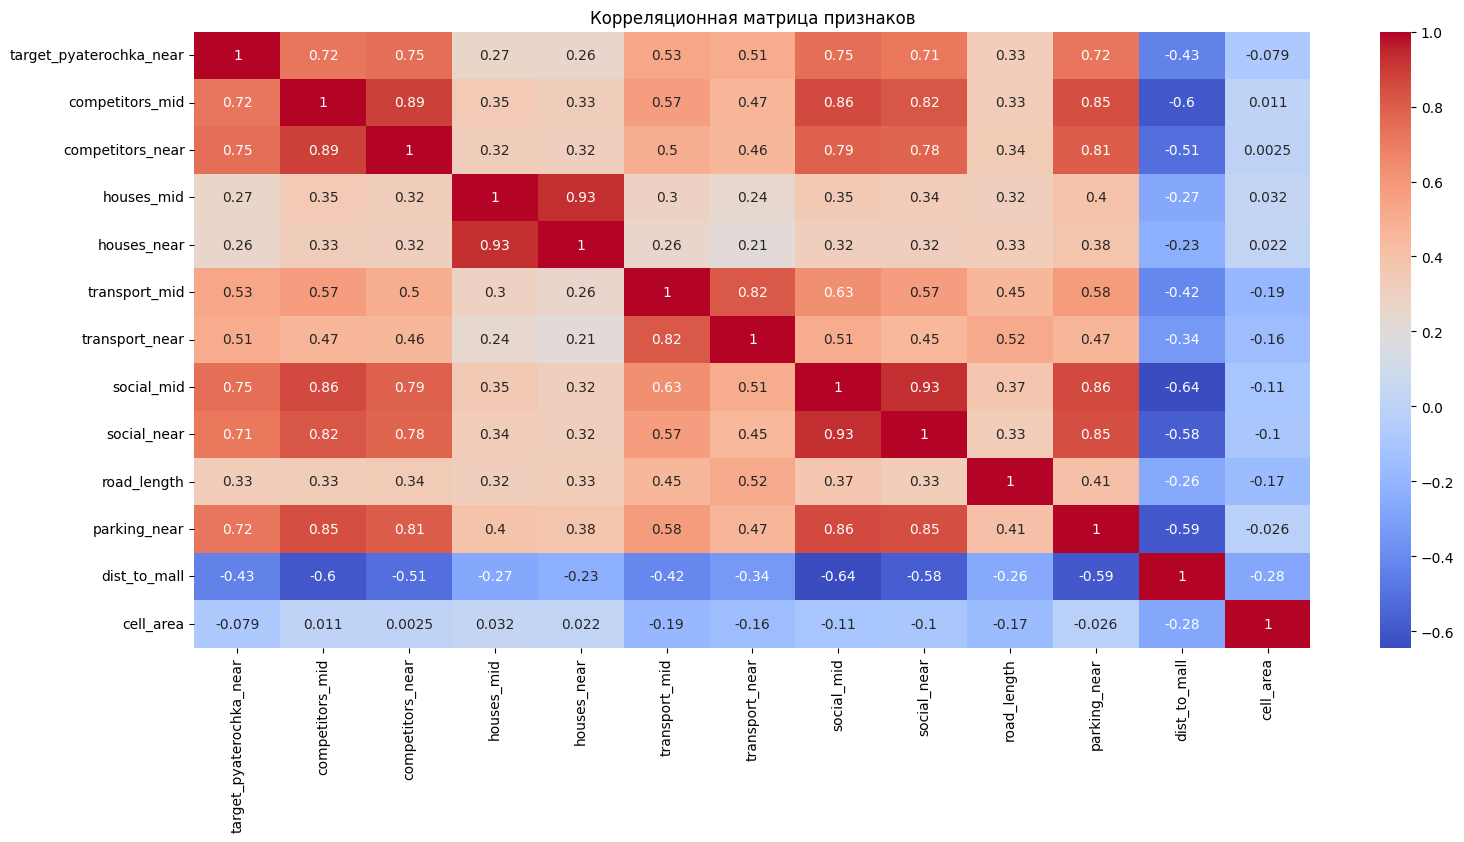

In [ ]:
corr_mat = main_gdf[feature_names].corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

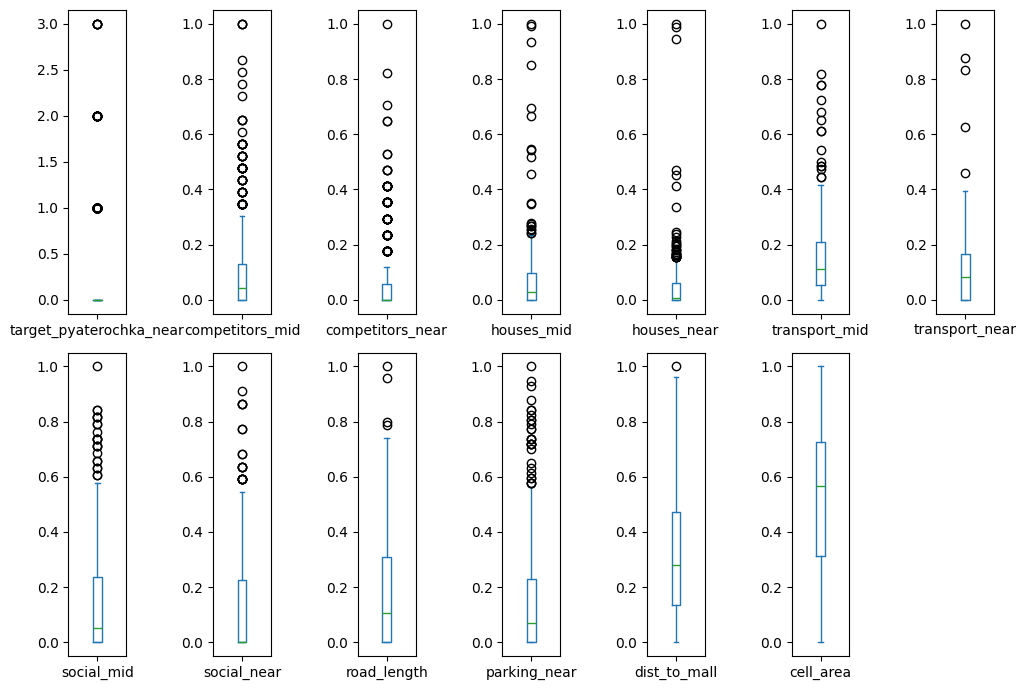

In [ ]:
main_gdf[feature_names].plot(kind='box', subplots=True, layout=(2, 7), figsize=(10, 7))
plt.tight_layout()

Подобные выбросы ожидаемы, т.к. расположение городской инфраструктуры очень неоднородно. Пропусков в данных нет, поэтому, не будем никак обрабатывать данные.

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Будем считать следующим образом:

- Вычитать баллы будем за наличие поблизости конкурентов - продуктовых магазинов (наибольший штраф), чем ближе конкурент - тем больше штраф

- в "двойных" признаках (которые учитываются и на 300, и на 700 м) будем считать больше баллов за ближайщие объекты и назначать меньше за дальние объекты

- больше всего баллов будем назначать за наличие жилых домов, транспортных остановок и иных зданий (детсадов, школ, больниц и т.д.) поблизости.

In [ ]:
# Расчет индекса привлекательности для магазина Пятерочка в Зеленограде
main_gdf['index_score'] = (
    # Конкуренты (отрицательный фактор)
    (main_gdf['competitors_near'] * -0.25) +      # конкуренты рядом (300м) сильно вредят
    (main_gdf['competitors_mid'] * -0.10) +       # конкуренты дальше (600м) вредят меньше

    # Жилые дома (положительный фактор)
    (main_gdf['houses_near'] * 0.10) +            # дома рядом - основной поток покупателей
    (main_gdf['houses_mid'] * 0.09) +             # дома в зоне 600м тоже важны, но меньше

    # Транспортная доступность
    (main_gdf['transport_near'] * 0.12) +         # остановки рядом - хорошо
    (main_gdf['transport_mid'] * 0.05) +          # дальний транспорт менее ценен

    # Социальные объекты (школы, поликлиники - привлекают людей)
    (main_gdf['social_near'] * 0.10) +
    (main_gdf['social_mid'] * 0.04) +

    # Парковки (важно для автомобилистов)
    (main_gdf['parking_near'] * 0.12) +

    # Длина дорог (связность территории, доступность)
    (main_gdf['road_length'] * 0.08) +

    # Расстояние до ТЦ (отрицательный фактор - чем ближе к ТЦ, тем больше конкуренция)
    # Нормализуем или инвертируем: чем меньше расстояние, тем хуже
    (-main_gdf['dist_to_mall'] * 0.005) +

    # Площадь ячейки (поправка на размер территории)
    (main_gdf['cell_area'] * 0.02)
)

# Нормировка индекса в диапазон (например, от 0 до 1 или стандартное масштабирование)
from sklearn.preprocessing import MinMaxScaler  # или StandardScaler
scaler = MinMaxScaler()  # или StandardScaler() как в оригинале
main_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(main_gdf['index_score']))

In [ ]:
main_gdf['index_score'].describe()

,index_score
count,445.000000
mean,0.318321
std,0.160615
min,0.000000
25%,0.194051
50%,0.277505
75%,0.391622
max,1.000000


<Axes: >

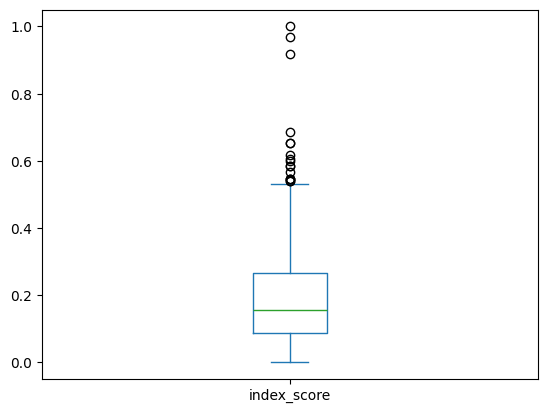

In [ ]:
main_gdf['index_score'].plot(kind='box')

In [ ]:
# Создаем карту
map_result = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=12, basemap='CartoDB.Positron')

# Добавляем H3 ячейки
map_result.add_data(
    main_gdf,
    column="index_score",
    cmap="OrRd",
    legend_title="index_score",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    }
)

# Отображаем карту
map_result

Map(center=[np.float64(55.9846158), np.float64(37.19995205)], controls=(ZoomControl(options=['position', 'zoom…

In [ ]:
features_for_clustering = [f for f in feature_names if f != 'target_pyaterochka_near']
X = main_gdf[features_for_clustering].copy()
y = main_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=features_for_clustering)
X_df.index = main_gdf.index
y.index = main_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (445, 12)


,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area
0,0.000000,0.000000,0.000000,0.000000,0.055556,0.083333,0.000000,0.000000,0.299764,0.000000,0.641744,0.502002
1,0.000000,0.000000,0.008333,0.011173,0.027778,0.000000,0.078947,0.136364,0.000000,0.000000,0.399290,0.106470
2,0.086957,0.058824,0.000000,0.000000,0.180556,0.125000,0.000000,0.000000,0.678036,0.157895,0.162581,0.557217
3,0.086957,0.000000,0.025000,0.000000,0.083333,0.000000,0.263158,0.318182,0.000000,0.052632,0.203969,0.584951
4,0.130435,0.176471,0.041667,0.022346,0.041667,0.000000,0.184211,0.227273,0.000000,0.403509,0.184704,0.610065
5,0.043478,0.058824,0.000000,0.000000,0.194444,0.166667,0.000000,0.000000,0.133109,0.087719,0.560815,0.754544
6,0.043478,0.058824,0.000000,0.000000,0.055556,0.000000,0.000000,0.000000,0.000000,0.192982,0.279350,0.495496
7,0.000000,0.000000,0.000000,0.000000,0.055556,0.000000,0.000000,0.000000,0.207369,0.000000,0.677250,0.210854
8,0.000000,0.000000,0.020833,0.005587,0.000000,0.000000,0.078947,0.090909,0.000000,0.122807,0.253388,0.595106
9,0.347826,0.176471,0.154167,0.067039,0.416667,0.270833,0.447368,0.363636,0.661431,0.421053,0.125311,0.390932


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

<Axes: title={'center': 'Важности признаков'}>

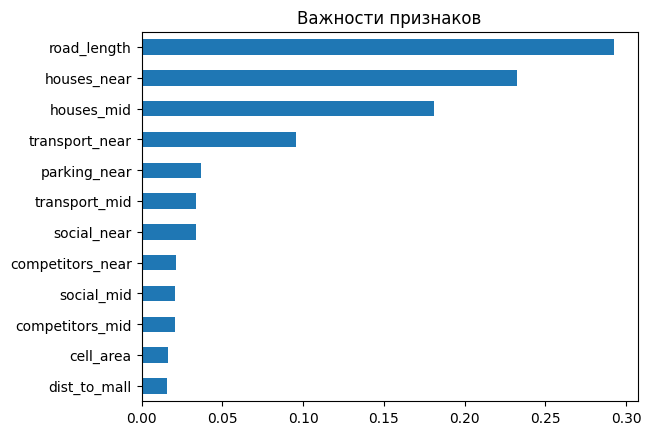

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=features_for_clustering)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

<Axes: title={'center': 'Важности признаков (без houses_near, houses_mid)'}>

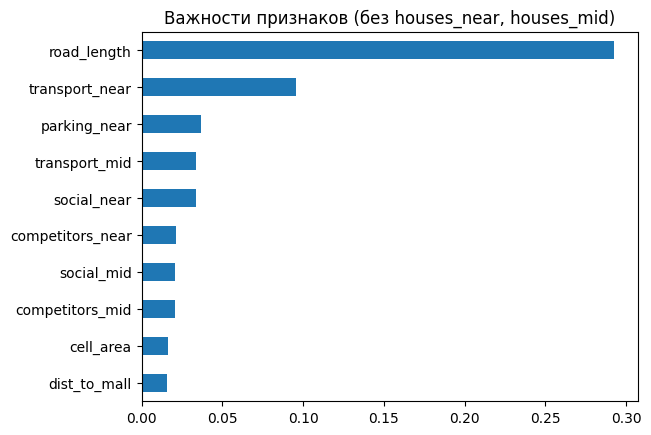

In [ ]:
# не учитывая близость жилых домов
feat2= [
    'competitors_mid',             # Конкуренты 600м
    'competitors_near',            # Конкуренты 300м
    'transport_mid',               # Транспорт 600м
    'transport_near',              # Транспорт 300м
    'social_mid',                  # Соцобъекты 600м
    'social_near',                 # Соцобъекты 300м
    'road_length',                 # Длина дорог в ячейке
    'parking_near',                # Парковки 300м
    'dist_to_mall',                # Расстояние до ТЦ
    'cell_area'                    # Площадь ячейки
    ]
feat_imp[feat2].sort_values().plot(kind='barh', title='Важности признаков (без houses_near, houses_mid)')

In [ ]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test,rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.865070,0.036740,0.060748
0,Random Forest,0.765764,0.046695,0.080040


In [ ]:
%%capture
!pip install kneed

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


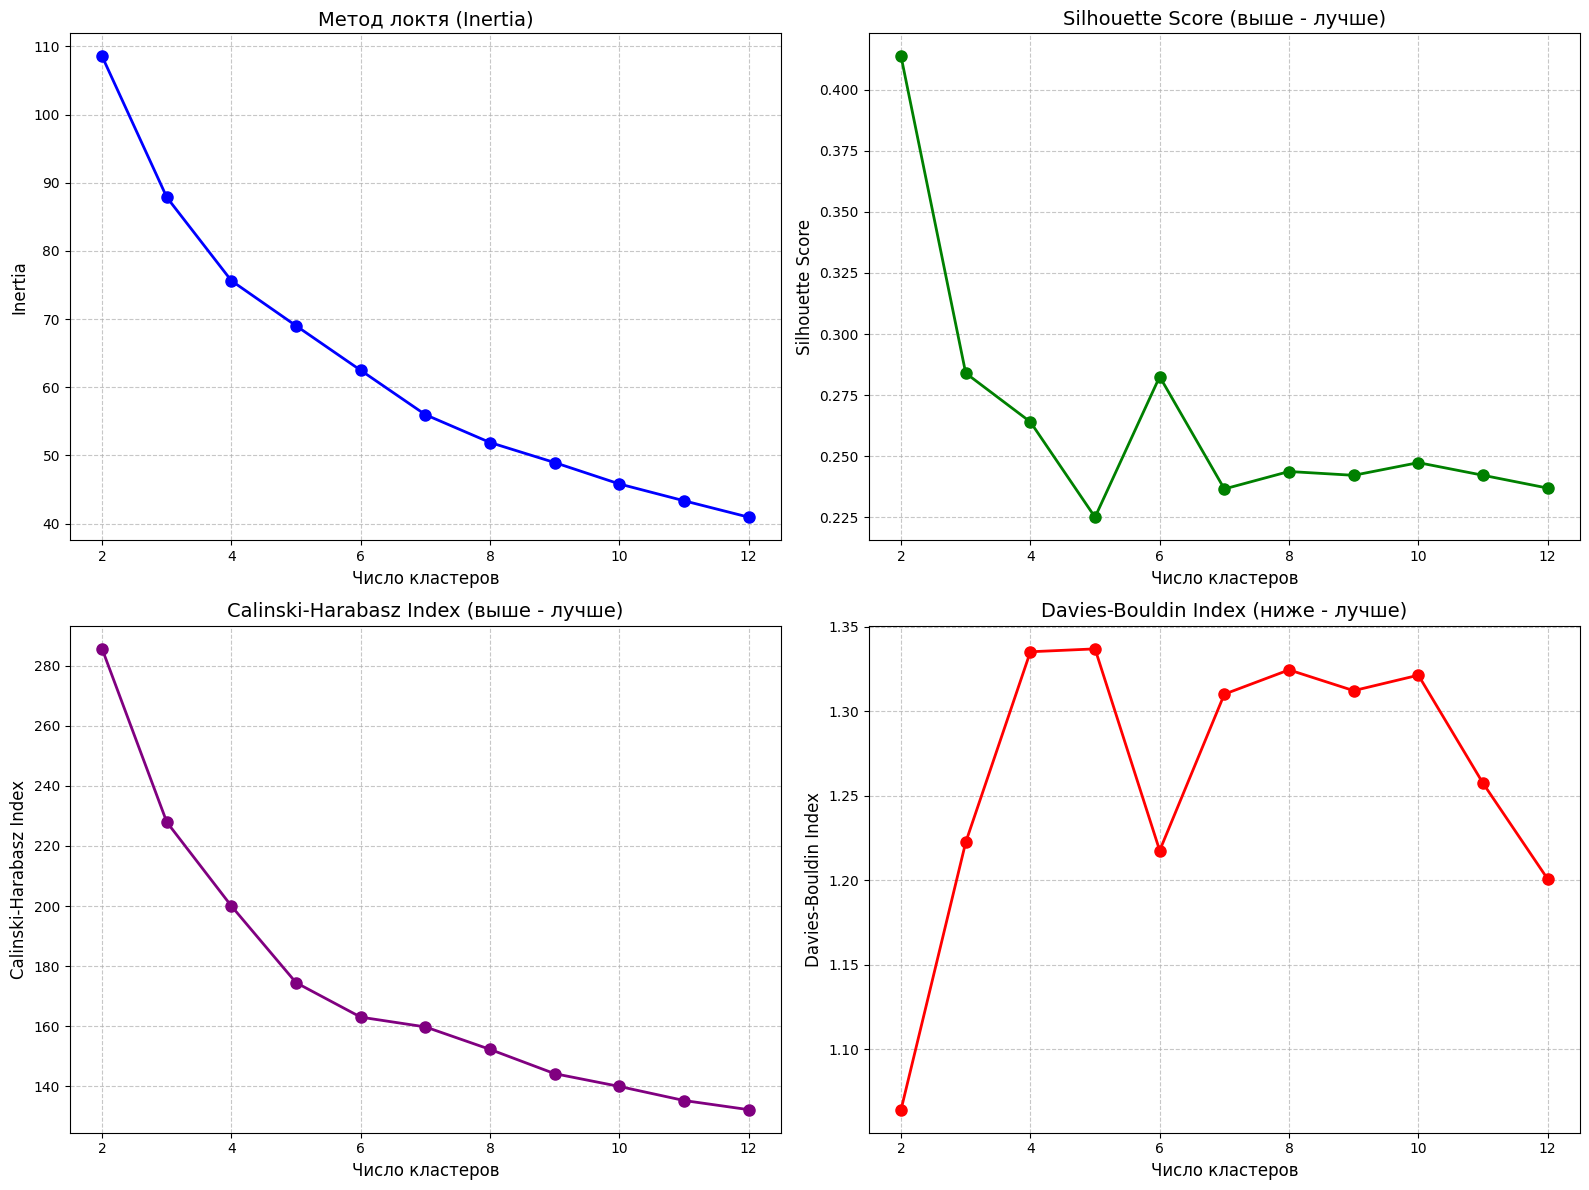


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 4
Silhouette Score: 2
Calinski-Harabasz Index: 2
Davies-Bouldin Index: 2

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,108.528175,0.413731,285.547270,1.064117
1,3,87.862180,0.283979,227.938456,1.222406
2,4,75.614530,0.263997,199.983310,1.335235
3,5,69.009559,0.224965,174.498475,1.336947
4,6,62.472870,0.282542,163.041602,1.217532
5,7,55.969468,0.236533,159.792074,1.310132
6,8,51.888838,0.243678,152.307974,1.324527
7,9,48.946500,0.242115,144.233632,1.312208
8,10,45.808648,0.247307,139.986378,1.321365
9,11,43.344788,0.242133,135.310207,1.257397


In [ ]:
# Улучшение модели с помощью кластеризации

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=8):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

optimal_clusters = find_optimal_clusters(X_df, max_k=12)

In [ ]:
optimal_clusters

{'inertia': np.int64(4),
 'silhouette': 2,
 'calinski': 2,
 'davies': 2,
 'metrics_df':     Число кластеров     Inertia  Silhouette Score  Calinski-Harabasz  \
 0                 2  108.528175          0.413731         285.547270   
 1                 3   87.862180          0.283979         227.938456   
 2                 4   75.614530          0.263997         199.983310   
 3                 5   69.009559          0.224965         174.498475   
 4                 6   62.472870          0.282542         163.041602   
 5                 7   55.969468          0.236533         159.792074   
 6                 8   51.888838          0.243678         152.307974   
 7                 9   48.946500          0.242115         144.233632   
 8                10   45.808648          0.247307         139.986378   
 9                11   43.344788          0.242133         135.310207   
 10               12   40.936861          0.236882         132.260034   
 
     Davies-Bouldin  
 0         1.

In [ ]:
optimal_k = [i for i in range(optimal_clusters['silhouette'], optimal_clusters['silhouette']+3)]
optimal_k

[2, 3, 4]

In [ ]:
# Визуализация

from sklearn.decomposition import PCA
import plotly.express as px

# казалось более приятным визуализировать в 3д
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_df)

for k in optimal_k:
    kmeans_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_plus.fit_predict(X_df)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (KMeans++, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

Попробуем использовать KMeans++ с K=6, данное разделение выглядит более информативным

In [ ]:
kmeans_plus = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
labels = kmeans_plus.fit_predict(X_df)
X_clust_df = X_df.copy()
X_clust_df['cluster'] = labels

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust_df, y, test_size=0.4, random_state=42)

gbc = GradientBoostingRegressor(learning_rate=0.5, max_depth=1, n_estimators=250, random_state=42)
gbc.fit(Xc_train, yc_train)
gbc_pred = gbc.predict(Xc_test)

r2_gbc = r2_score(yc_test, gbc_pred)
mae_gbc = mean_absolute_error(yc_test, gbc_pred)
rmse_gbc = np.sqrt(mean_squared_error(yc_test, gbc_pred))
print(f'Gradient Boosting, R2: {r2_gbc}; MAE: {mae_gbc}; RMSE: {rmse_gbc}')

Gradient Boosting, R2: 0.9107267935071112; MAE: 0.029556872824119496; RMSE: 0.04941279354763419


#Сравнение:
R2 без кластеров: 0.865070

R2 с кластерами: 0.9107267935071112

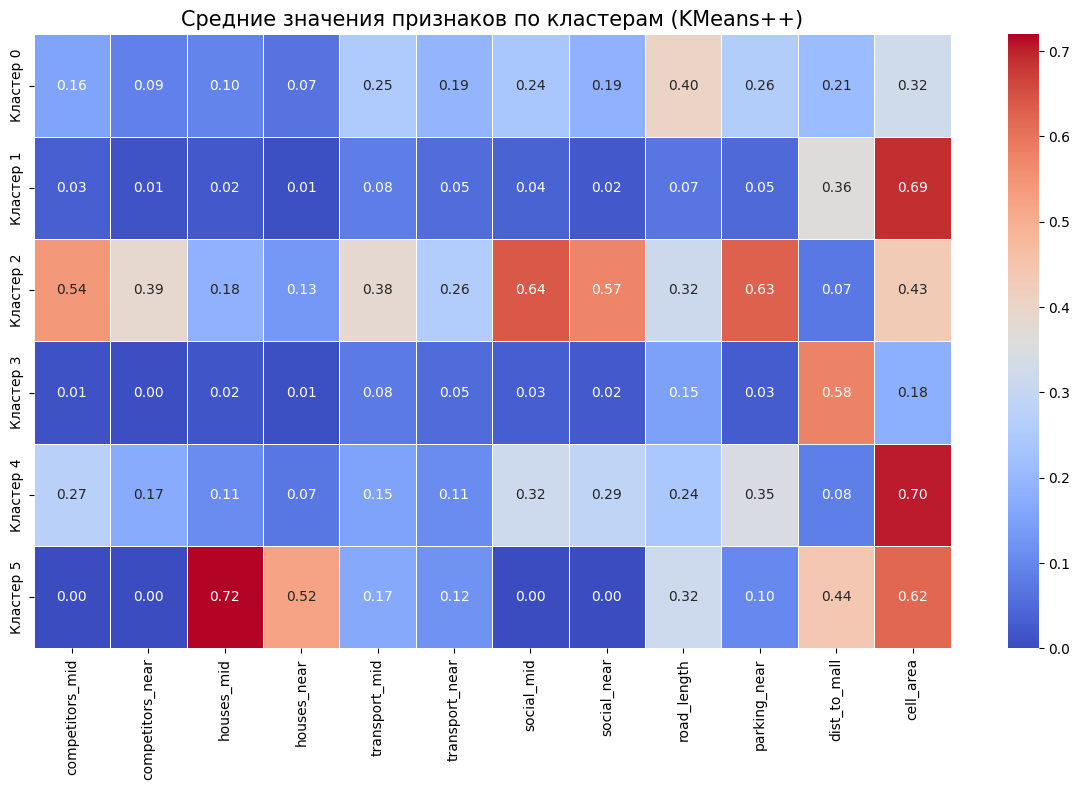

In [ ]:
X_clust_df['index_score'] = y
X_clust_df.groupby('cluster')['index_score'].describe()

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features_for_clustering
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса

   **Ответ:** Веса были подобраны ранее и обоснованы.

   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [ ]:
clust_gdf = main_gdf.copy()
clust_gdf['index_score'] = y
clust_gdf['cluster'] = X_clust_df['cluster'].astype(str)
bins = [0.0, 0.5, 0.7, 0.8, 0.9, 1.0]

labels = ['1', '2', '3', '4', '5']

clust_gdf['cat'] = pd.cut(
    clust_gdf['index_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

m4 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m4.add_data(
    clust_gdf,
    column="cat",
    cmap="OrRd",
    legend_title="cat",
    layer_name="H3 Сетка",
    scheme='EqualInterval',
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m4.add_gdf(x5_gdf, layer_name='X5 Location', info_mode='on_click')
m4

Map(center=[np.float64(55.9846158), np.float64(37.19995205)], controls=(ZoomControl(options=['position', 'zoom…

In [ ]:
best_gdf = clust_gdf.sort_values('index_score', ascending=False).head(10)
best_gdf

,h3_index,geometry,target_pyaterochka_near,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area,index_score,cluster,cat
339,8911aa00023ffff,"POLYGON ((4136524.444 7559165.296, 4136792.421...",0.0,0.000000,0.000000,0.991667,0.988827,0.236111,0.083333,0.000000,0.000000,0.643110,0.122807,0.437603,0.643896,1.000000,5,5
93,8911aa0003bffff,"POLYGON ((4136178.731 7558650.771, 4136446.693...",0.0,0.000000,0.000000,0.933333,1.000000,0.166667,0.083333,0.000000,0.000000,0.562752,0.157895,0.445810,0.597045,0.967409,5,5
348,8911aa0022bffff,"POLYGON ((4138356.36 7554620.313, 4138624.177 ...",3.0,0.652174,0.411765,0.175000,0.117318,0.722222,0.625000,0.815789,0.681818,1.000000,0.807018,0.049454,0.388979,0.905884,2,5
402,8911aa0002bffff,"POLYGON ((4136753.532 7558597.1, 4137021.489 7...",0.0,0.000000,0.000000,1.000000,0.944134,0.083333,0.083333,0.000000,0.000000,0.535450,0.017544,0.377510,0.612017,0.900609,5,5
70,8911aa0020fffff,"POLYGON ((4137436.149 7554160, 4137703.955 755...",1.0,0.608696,0.294118,0.179167,0.117318,0.819444,0.875000,0.631579,0.500000,0.956613,0.368421,0.021691,0.327253,0.864387,2,4
209,8911aa00277ffff,"POLYGON ((4138010.677 7554106.164, 4138278.479...",1.0,0.434783,0.235294,0.158333,0.117318,0.777778,0.833333,0.500000,0.363636,0.587057,0.456140,0.046292,0.342195,0.820264,2,4
130,8911aa00217ffff,"POLYGON ((4136632.678 7554781.74, 4136900.51 7...",2.0,0.478261,0.352941,0.200000,0.167598,0.388889,0.375000,0.789474,1.000000,0.303573,0.736842,0.052275,0.344139,0.780446,2,3
302,8911aa0020bffff,"POLYGON ((4137090.567 7553645.861, 4137358.359...",1.0,0.391304,0.235294,0.179167,0.117318,0.611111,0.312500,0.736842,0.454545,0.603315,0.719298,0.080984,0.280477,0.776289,2,3
260,8911aa01cd7ffff,"POLYGON ((4139388.59 7553430.325, 4139656.362 ...",0.0,0.086957,0.058824,0.095833,0.067039,0.222222,0.250000,0.368421,0.500000,0.736600,0.350877,0.233081,0.340220,0.751472,0,3
246,8911aa01c9bffff,"POLYGON ((4139159.786 7553998.359, 4139427.578...",1.0,0.347826,0.352941,0.179167,0.128492,0.222222,0.083333,0.631579,0.863636,0.665699,0.877193,0.172806,0.372067,0.749489,2,3


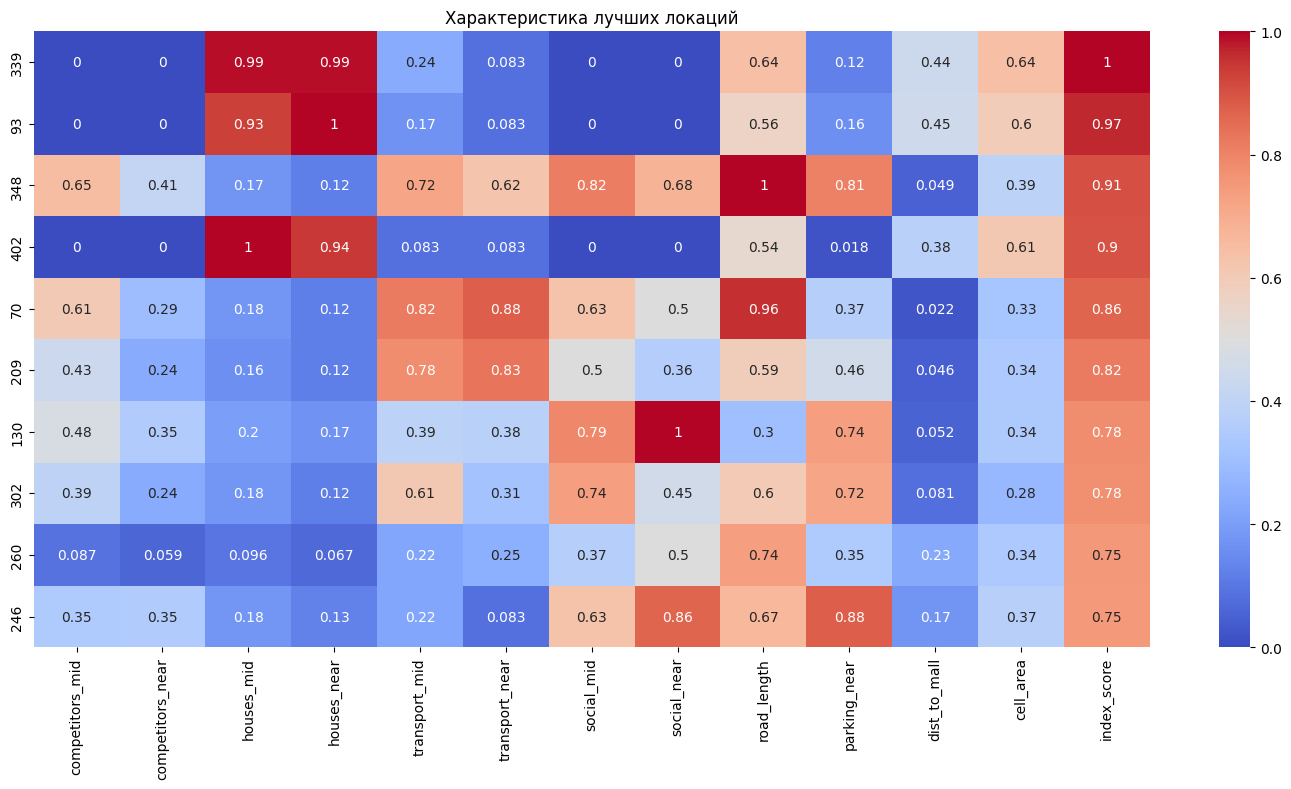

In [ ]:
fin_feat = features_for_clustering.copy()
fin_feat.append('index_score')

plt.figure(figsize=(18, 8))
sns.heatmap(best_gdf[fin_feat], annot=True, cmap='coolwarm')
plt.title('Характеристика лучших локаций')
plt.show()

In [ ]:
# Подготовьте отдельную карту фокуса на лучших локациях

m5 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

data = []
for h3_id in best_gdf['h3_index']:
    lat, lng = h3.h3_to_geo(h3_id)
    data.append({'h3_id': h3_id, 'lat': lat, 'lng': lng})

df_centers = pd.DataFrame(data)
gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"  # WGS 84 coordinate system
)

m5.add_gdf(
    gdf_centers,
    layer_name="best points",
    info_mode='on_click'
)

m5.add_data(
    best_gdf,
    column='index_score',
    cmap="Greens",
    k=11,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m5

Map(center=[np.float64(55.9846158), np.float64(37.19995205)], controls=(ZoomControl(options=['position', 'zoom…

#Бизнес рекомендации
|Номер|Коорд-ты|Адрес|Index Score|Хар-ки|Преимущества и риски|
|-|-|-|-|-|-|
|1|56.003678, 37.157428|улица Алабушева, 19А|1.0|Находится в частном секотре <br> Нет конкуренции <br> Плотная жилая застройка <br>Рядом с автобусной остановкой по пути к частному сектору|**Плюсы:** Полное отсутвие конкуренции <br><br> **Риски:** Непостоянное проживание людей в частном секторе (если это вариант дачных домов)|
|2|55.982160, 37.163133|Зеленоград, к1815|0.98|Наличие рядом школ <br> Плотная многоквартирная застройка <br> Рядом парковка, банк <br> Есть непродуктовые магазины рядом|**Плюсы**: Много людей вечером (большой поток людей возвращается по домам)<br><br> **Риски**: Рядом уже есть бюджетные магазины другого бренда|
|3|55.978886, 37.171532|Привокзальная площадь, 1|0.978| Напротив выхода с ж/д станции и рядом автобусные остановка;<br>Наличие парковки (ТЦ)<br> Здание является ТЦ, нет продуктовых магазинов поблизости|**Плюсы**: Отличная доступность на транспорте<br> высокий поток пассажиров, удобно покупать что-то по пути <br><br>**Риски**: Высокая арендная плата|
|4|55.981545, 37.180210|Зеленоград, к830|0.975|Находится в многоквартирном доме в спальном районе<br>Рядом есть автобусная остановка;<br>Вблизи расположены дет.сады, школы и др. соц. инфраструктура|**Плюсы**: находится в плотной жилой хастройке<br>Дом находится у большого проспекта, большая проходимость<br><br>**Риски**: Пятерочка в соседнем квартале уже есть|
|5|55.967814, 37.186408|Зеленоград, к2302|0.954|<br>Находится в ЖК;<br>Рядом ТЦ и парковки<br>Нет конкурентов в ценовом сегменте Пятерочки;<br>|**Плюсы**: Много семей с детьми приезжают в ТЦ рядом<br>Автобусная остановка напротив здания<br><br>**Риски**: Высокая арендная плата и сложности с арендой помещения<br>|

# Общие рекомендации по стратегии территориального развития для выбранного бизнеса
1. Необходимо открываться рядом с жилыми домами, в густонаселённых районах.
2. Нужно учитывать конкуренцию: если открывать Пятерочку рядом с магазином другого бренда, то нужно переманивать покупателей акциями и бонусными программами. Также нужно открываться на относительно удаленном расстоянии от своих же Пятерочек.
3. Необходимо учитывать проходимость и плотность трафика - очень выгодно открываться рядом с остановками, магазинами, школами, ведь так людям удобнее заходить по пути.

4. Для начала лучше всего будет открыть Пятерочку в частном секторе, который находится в стороне от центральной части города (выяснив сколько людей проживает там на постоянной основе, а как в летнем доме, иначе будет мертвый сезон зимой).

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.